# Preprocessing Data untuk Model TimeMixer

Notebook ini menjelaskan proses preprocessing data dari mentah hingga siap digunakan untuk model TimeMixer. Dataset yang diproses meliputi:
- **ETTh1** (Electricity Transformer Temperature - Hourly)
- **ETTh2** (Electricity Transformer Temperature - Hourly)
- **Weather** (Weather dataset)
- **Traffic** (Traffic dataset)

## Parameter TimeMixer yang Digunakan:
- **seq_len**: 168 (lookback window)
- **pred_len**: 96, 192, 336, 720 (prediction horizons)
- **features**: 'M' (multivariate)
- **d_model**: 16
- **d_ff**: 32
- **down_sampling_layers**: 3
- **down_sampling_window**: 2
- **timeenc**: 0 (discrete time features) atau 1 (continuous time features)

## 1. Import Required Libraries

Import semua library yang diperlukan untuk preprocessing data

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')

# Set style untuk visualisasi
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Libraries imported successfully!
NumPy version: 2.3.5
Pandas version: 2.3.3


## 2. Load Raw Datasets

Memuat dataset mentah dari file CSV. Pastikan dataset tersedia di folder `dataset/`

In [2]:
# Path ke dataset
dataset_paths = {
    'ETTh1': './dataset/ETT-small/ETTh1.csv',
    'ETTh2': './dataset/ETT-small/ETTh2.csv',
    'Weather': './dataset/weather/weather.csv',
    'Traffic': './dataset/traffic/traffic.csv'
}

# Load datasets
datasets = {}
for name, path in dataset_paths.items():
    if os.path.exists(path):
        datasets[name] = pd.read_csv(path)
        print(f"✓ {name} loaded: {datasets[name].shape}")
    else:
        print(f"✗ {name} not found at {path}")

print(f"\nTotal datasets loaded: {len(datasets)}")

✓ ETTh1 loaded: (17420, 8)
✓ ETTh2 loaded: (17420, 8)
✓ Weather loaded: (52696, 22)
✓ Traffic loaded: (17544, 863)

Total datasets loaded: 4


## 3. Explore Dataset Structures

Melihat struktur data, kolom, tipe data, dan statistik dasar dari setiap dataset

In [3]:
# Informasi dataset ETTh1
print("="*60)
print("ETTh1 Dataset")
print("="*60)
print(f"Shape: {datasets['ETTh1'].shape}")
print(f"\nColumns: {list(datasets['ETTh1'].columns)}")
print(f"\nFirst 5 rows:")
print(datasets['ETTh1'].head())
print(f"\nData types:")
print(datasets['ETTh1'].dtypes)
print(f"\nBasic statistics:")
print(datasets['ETTh1'].describe())

ETTh1 Dataset
Shape: (17420, 8)

Columns: ['date', 'HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT']

First 5 rows:
                  date   HUFL   HULL   MUFL   MULL   LUFL   LULL         OT
0  2016-07-01 00:00:00  5.827  2.009  1.599  0.462  4.203  1.340  30.531000
1  2016-07-01 01:00:00  5.693  2.076  1.492  0.426  4.142  1.371  27.787001
2  2016-07-01 02:00:00  5.157  1.741  1.279  0.355  3.777  1.218  27.787001
3  2016-07-01 03:00:00  5.090  1.942  1.279  0.391  3.807  1.279  25.044001
4  2016-07-01 04:00:00  5.358  1.942  1.492  0.462  3.868  1.279  21.948000

Data types:
date     object
HUFL    float64
HULL    float64
MUFL    float64
MULL    float64
LUFL    float64
LULL    float64
OT      float64
dtype: object

Basic statistics:
               HUFL          HULL          MUFL          MULL          LUFL  \
count  17420.000000  17420.000000  17420.000000  17420.000000  17420.000000   
mean       7.375141      2.242242      4.300239      0.881568      3.066062   
std        7.

In [4]:
# Informasi dataset ETTh2
print("="*60)
print("ETTh2 Dataset")
print("="*60)
print(f"Shape: {datasets['ETTh2'].shape}")
print(f"\nColumns: {list(datasets['ETTh2'].columns)}")
print(f"\nFirst 5 rows:")
print(datasets['ETTh2'].head())
print(f"\nBasic statistics:")
print(datasets['ETTh2'].describe())

ETTh2 Dataset
Shape: (17420, 8)

Columns: ['date', 'HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT']

First 5 rows:
                  date       HUFL    HULL       MUFL   MULL   LUFL   LULL  \
0  2016-07-01 00:00:00  41.130001  12.481  36.535999  9.355  4.424  1.311   
1  2016-07-01 01:00:00  37.528000  10.136  33.936001  7.532  4.435  1.215   
2  2016-07-01 02:00:00  37.946999  11.309  35.330002  9.007  2.100  0.000   
3  2016-07-01 03:00:00  38.952000  11.895  35.543999  9.436  3.380  1.215   
4  2016-07-01 04:00:00  38.113998  11.476  35.410000  9.623  2.036  0.000   

          OT  
0  38.661999  
1  37.124001  
2  36.465000  
3  33.608501  
4  31.850500  

Basic statistics:
               HUFL          HULL          MUFL          MULL          LUFL  \
count  17420.000000  17420.000000  17420.000000  17420.000000  17420.000000   
mean      37.193346      8.537565     43.830356      8.322694     -3.423605   
std       10.218855      6.020442     13.056798      4.366059      6.14

In [5]:
# Informasi dataset Weather
print("="*60)
print("Weather Dataset")
print("="*60)
print(f"Shape: {datasets['Weather'].shape}")
print(f"\nColumns ({len(datasets['Weather'].columns)}): {list(datasets['Weather'].columns[:10])}...")
print(f"\nFirst 5 rows:")
print(datasets['Weather'].head())
print(f"\nBasic statistics (first 5 features):")
print(datasets['Weather'].iloc[:, :6].describe())

Weather Dataset
Shape: (52696, 22)

Columns (22): ['date', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)']...

First 5 rows:
                  date  p (mbar)  T (degC)  Tpot (K)  Tdew (degC)  rh (%)  \
0  2020-01-01 00:10:00   1008.89      0.71    273.18        -1.33    86.1   
1  2020-01-01 00:20:00   1008.76      0.75    273.22        -1.44    85.2   
2  2020-01-01 00:30:00   1008.66      0.73    273.21        -1.48    85.1   
3  2020-01-01 00:40:00   1008.64      0.37    272.86        -1.64    86.3   
4  2020-01-01 00:50:00   1008.61      0.33    272.82        -1.50    87.4   

   VPmax (mbar)  VPact (mbar)  VPdef (mbar)  sh (g/kg)  ...  wv (m/s)  \
0          6.43          5.54          0.89       3.42  ...      1.02   
1          6.45          5.49          0.95       3.39  ...      0.43   
2          6.44          5.48          0.96       3.39  ...      0.61   
3          6.27          5.41          0.86   

In [6]:
# Informasi dataset Traffic
print("="*60)
print("Traffic Dataset")
print("="*60)
print(f"Shape: {datasets['Traffic'].shape}")
print(f"\nColumns ({len(datasets['Traffic'].columns)}): {list(datasets['Traffic'].columns[:10])}...")
print(f"\nFirst 5 rows (first 5 features):")
print(datasets['Traffic'].iloc[:, :6].head())
print(f"\nBasic statistics (first 5 features):")
print(datasets['Traffic'].iloc[:, :6].describe())

Traffic Dataset
Shape: (17544, 863)

Columns (863): ['date', '0', '1', '2', '3', '4', '5', '6', '7', '8']...

First 5 rows (first 5 features):
                  date       0       1       2       3       4
0  2016-07-01 02:00:00  0.0048  0.0146  0.0289  0.0142  0.0064
1  2016-07-01 03:00:00  0.0072  0.0148  0.0350  0.0174  0.0084
2  2016-07-01 04:00:00  0.0040  0.0101  0.0267  0.0124  0.0049
3  2016-07-01 05:00:00  0.0039  0.0060  0.0218  0.0090  0.0029
4  2016-07-01 06:00:00  0.0042  0.0055  0.0191  0.0082  0.0024

Basic statistics (first 5 features):
                  0             1             2             3             4
count  17544.000000  17544.000000  17544.000000  17544.000000  17544.000000
mean       0.049324      0.046016      0.105870      0.056633      0.026812
std        0.062469      0.048398      0.082205      0.036746      0.035872
min        0.000000      0.000000      0.000000      0.000000      0.000000
25%        0.008900      0.018100      0.035600      0.026800

### Visualisasi Data Mentah

Mari kita visualisasi beberapa fitur dari setiap dataset untuk memahami pola temporal

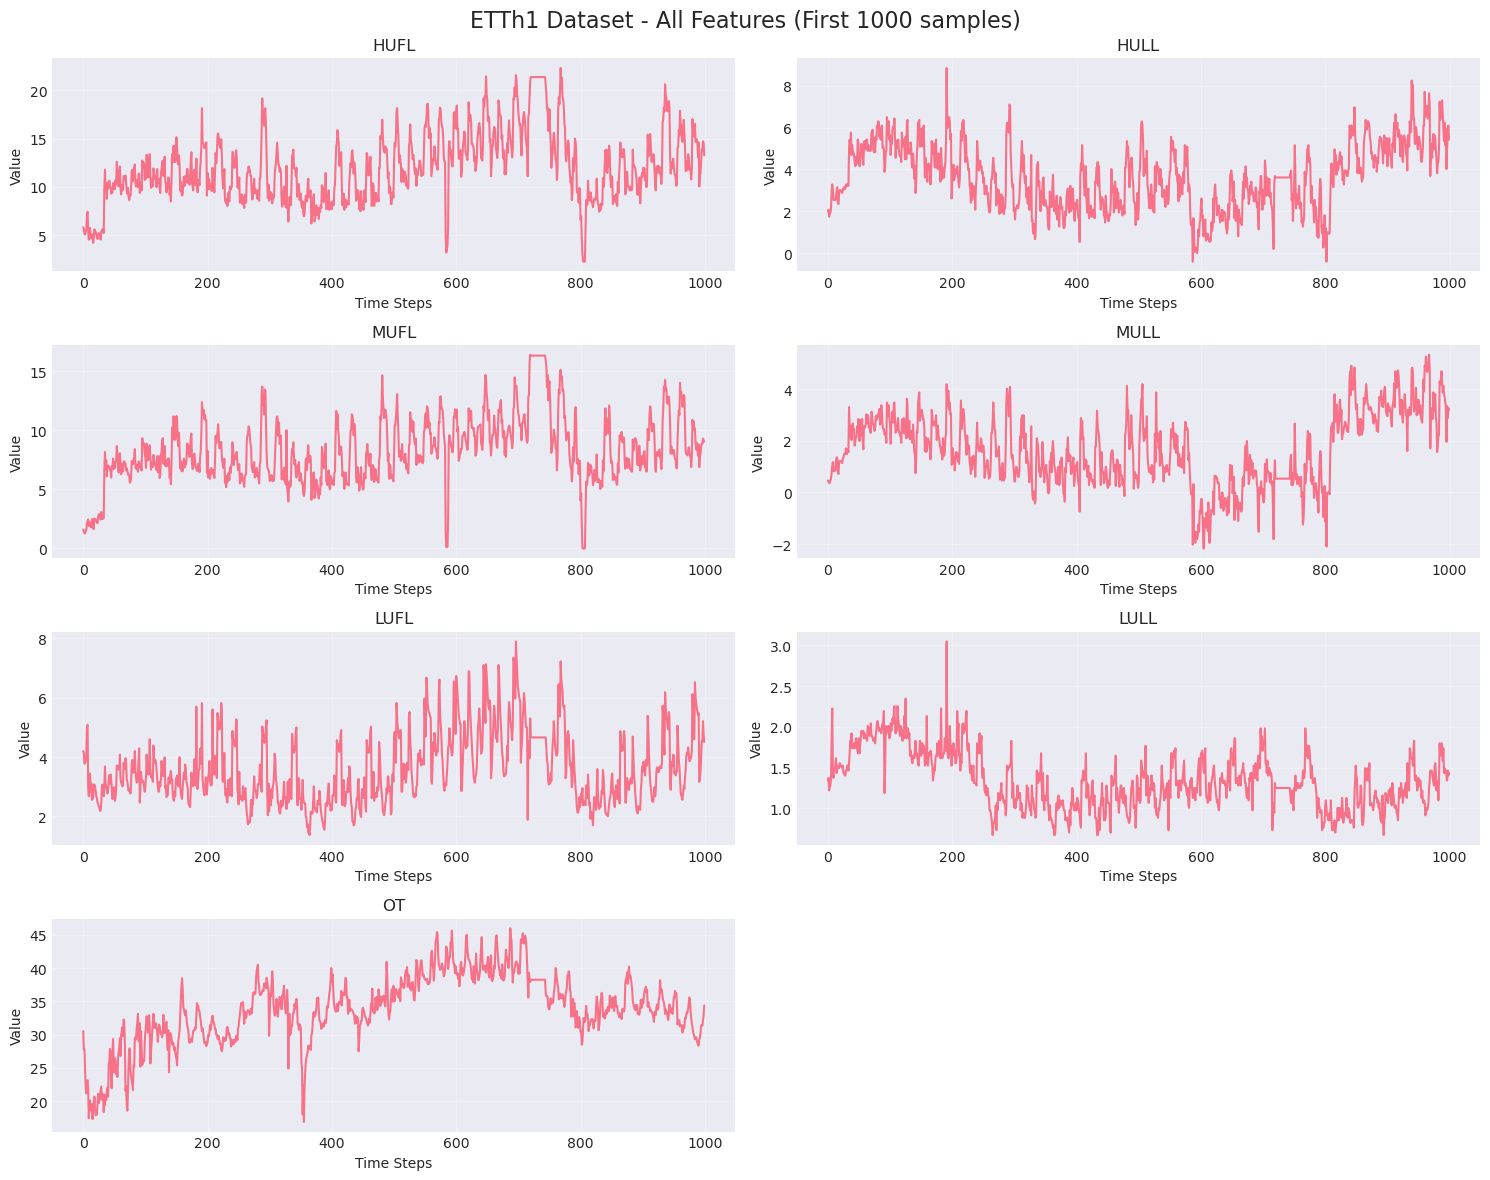

In [7]:
# Visualisasi ETTh1
fig, axes = plt.subplots(4, 2, figsize=(15, 12))
fig.suptitle('ETTh1 Dataset - All Features (First 1000 samples)', fontsize=16)

feature_cols = ['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT']
for idx, col in enumerate(feature_cols):
    row = idx // 2
    col_idx = idx % 2
    axes[row, col_idx].plot(datasets['ETTh1'][col][:1000])
    axes[row, col_idx].set_title(f'{col}')
    axes[row, col_idx].set_xlabel('Time Steps')
    axes[row, col_idx].set_ylabel('Value')
    axes[row, col_idx].grid(True, alpha=0.3)

# Hapus subplot kosong
fig.delaxes(axes[3, 1])
plt.tight_layout()
plt.show()

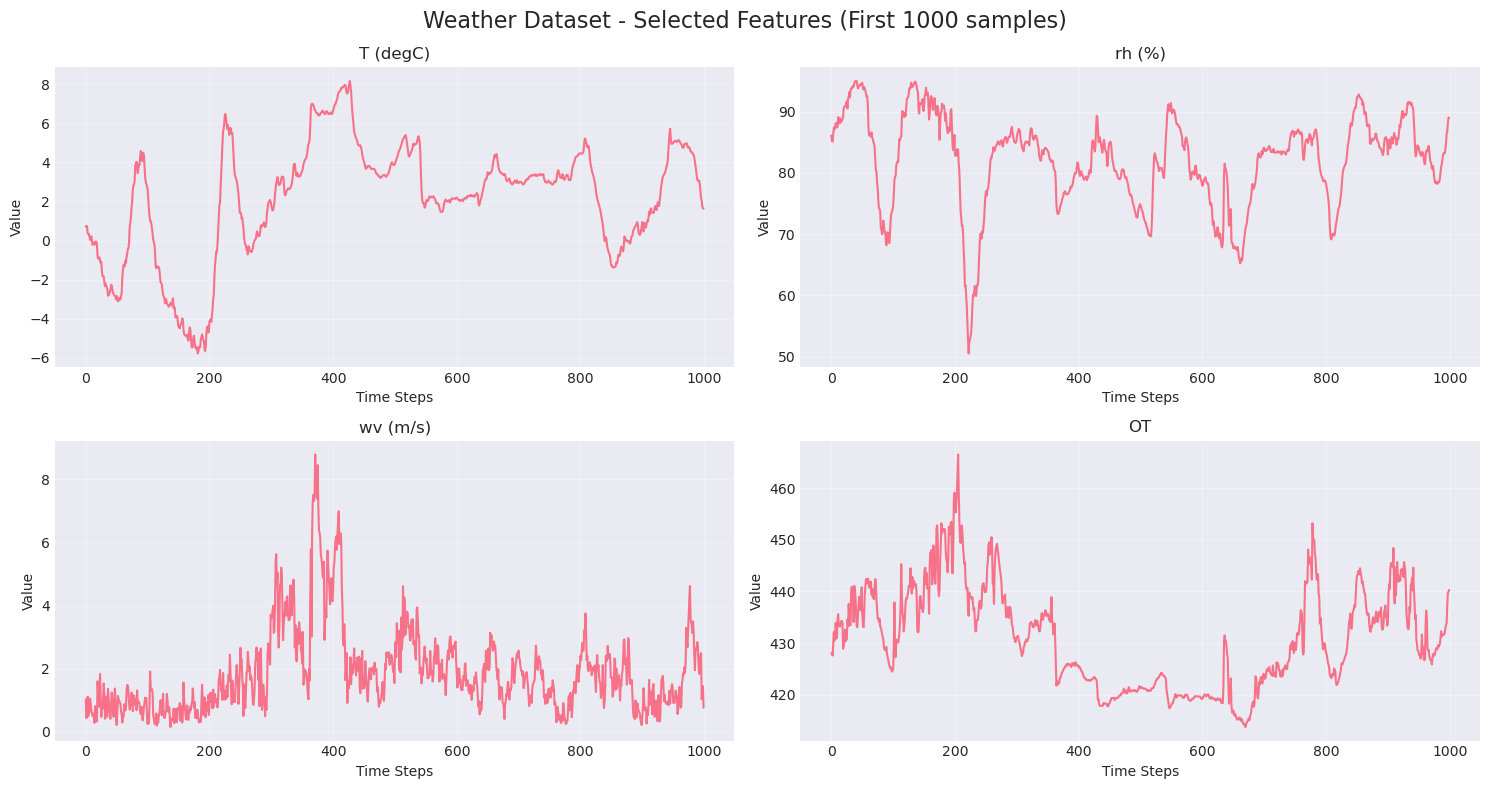

In [8]:
# Visualisasi Weather (beberapa fitur saja)
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
fig.suptitle('Weather Dataset - Selected Features (First 1000 samples)', fontsize=16)

# Pilih beberapa fitur untuk divisualisasi
weather_features = ['T (degC)', 'rh (%)', 'wv (m/s)', 'OT']
for idx, col in enumerate(weather_features):
    if col in datasets['Weather'].columns:
        row = idx // 2
        col_idx = idx % 2
        axes[row, col_idx].plot(datasets['Weather'][col][:1000])
        axes[row, col_idx].set_title(f'{col}')
        axes[row, col_idx].set_xlabel('Time Steps')
        axes[row, col_idx].set_ylabel('Value')
        axes[row, col_idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Handle Missing Values

Cek dan tangani nilai yang hilang pada setiap dataset

In [9]:
# Cek missing values untuk semua dataset
print("Missing Values Check")
print("="*60)

for name, df in datasets.items():
    missing = df.isnull().sum()
    total_missing = missing.sum()
    
    print(f"\n{name}:")
    print(f"  Total missing values: {total_missing}")
    
    if total_missing > 0:
        print(f"  Columns with missing values:")
        for col in missing[missing > 0].index:
            print(f"    - {col}: {missing[col]} ({missing[col]/len(df)*100:.2f}%)")
    else:
        print(f"  ✓ No missing values found")

Missing Values Check

ETTh1:
  Total missing values: 0
  ✓ No missing values found

ETTh2:
  Total missing values: 0
  ✓ No missing values found

Weather:
  Total missing values: 0
  ✓ No missing values found

Traffic:
  Total missing values: 0
  ✓ No missing values found


In [10]:
# Handle missing values jika ada
# Untuk time series, biasanya menggunakan forward fill atau interpolation

datasets_clean = {}

for name, df in datasets.items():
    df_clean = df.copy()
    
    if df.isnull().sum().sum() > 0:
        print(f"\nHandling missing values in {name}...")
        # Forward fill untuk kolom numerik
        numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
        df_clean[numeric_cols] = df_clean[numeric_cols].fillna(method='ffill')
        # Jika masih ada (di awal), gunakan backward fill
        df_clean[numeric_cols] = df_clean[numeric_cols].fillna(method='bfill')
        print(f"  ✓ Missing values handled")
    
    datasets_clean[name] = df_clean

print("\n" + "="*60)
print("All datasets cleaned successfully!")


All datasets cleaned successfully!


## 5. Parse dan Extract Time Features

Konversi kolom date menjadi datetime dan ekstrak fitur temporal sesuai dengan parameter TimeMixer

In [11]:
def extract_time_features(df, timeenc=0, freq='h'):
    """
    Extract time features dari kolom date
    
    Args:
        df: DataFrame dengan kolom 'date'
        timeenc: 0 untuk discrete features, 1 untuk continuous features
        freq: frequency ('h' untuk hourly, 't' untuk minute, dll)
    
    Returns:
        DataFrame dengan time features
    """
    df_stamp = df[['date']].copy()
    df_stamp['date'] = pd.to_datetime(df_stamp['date'])
    
    if timeenc == 0:
        # Discrete time features (TimeMixer default)
        df_stamp['month'] = df_stamp['date'].dt.month
        df_stamp['day'] = df_stamp['date'].dt.day
        df_stamp['weekday'] = df_stamp['date'].dt.weekday
        df_stamp['hour'] = df_stamp['date'].dt.hour
        
        # Untuk minute-level data
        if freq == 't':
            df_stamp['minute'] = df_stamp['date'].dt.minute
            df_stamp['minute'] = df_stamp['minute'] // 15  # Binning ke 15 menit
        
        # Drop kolom date, return hanya time features
        return df_stamp.drop(['date'], axis=1)
    
    else:
        # Continuous time features (menggunakan time_features dari utils)
        # Ini akan diimplementasikan menggunakan fungsi time_features
        print("Continuous time encoding akan menggunakan sin/cos encoding")
        # Untuk simplicity, kita gunakan discrete dulu
        return extract_time_features(df, timeenc=0, freq=freq)

# Test dengan ETTh1
print("Testing time feature extraction with ETTh1...")
time_features_etth1 = extract_time_features(datasets_clean['ETTh1'], timeenc=0, freq='h')
print(f"\nTime features shape: {time_features_etth1.shape}")
print(f"\nTime features columns: {list(time_features_etth1.columns)}")
print(f"\nFirst 5 rows:")
print(time_features_etth1.head())

Testing time feature extraction with ETTh1...

Time features shape: (17420, 4)

Time features columns: ['month', 'day', 'weekday', 'hour']

First 5 rows:
   month  day  weekday  hour
0      7    1        4     0
1      7    1        4     1
2      7    1        4     2
3      7    1        4     3
4      7    1        4     4


## 6. Data Splitting (Train/Val/Test)

Split data mengikuti protokol yang digunakan dalam TimeMixer:
- **ETTh1/ETTh2**: Train (12 months), Val (4 months), Test (8 months)
- **Weather/Traffic**: Train (70%), Val (10%), Test (20%)

In [12]:
def get_data_borders(dataset_name, df_length, seq_len):
    """
    Hitung border indices untuk train/val/test split
    
    Returns:
        borders: dict dengan keys 'train', 'val', 'test'
                 setiap value adalah tuple (start, end)
    """
    if 'ETTh' in dataset_name:
        # ETT datasets: 12/4/8 months
        # 1 month ~ 30 days * 24 hours = 720
        border1s = [0, 
                    12 * 30 * 24 - seq_len,  # val start
                    12 * 30 * 24 + 4 * 30 * 24 - seq_len]  # test start
        border2s = [12 * 30 * 24,  # train end
                    12 * 30 * 24 + 4 * 30 * 24,  # val end
                    12 * 30 * 24 + 8 * 30 * 24]  # test end
    else:
        # Weather, Traffic: 70/10/20 split
        num_train = int(df_length * 0.7)
        num_test = int(df_length * 0.2)
        num_vali = df_length - num_train - num_test
        
        border1s = [0,
                    num_train - seq_len,
                    df_length - num_test - seq_len]
        border2s = [num_train,
                    num_train + num_vali,
                    df_length]
    
    return {
        'train': (border1s[0], border2s[0]),
        'val': (border1s[1], border2s[1]),
        'test': (border1s[2], border2s[2])
    }

# Test untuk setiap dataset
seq_len = 168  # Parameter TimeMixer default

print("Data Split Borders:")
print("="*60)

for name, df in datasets_clean.items():
    borders = get_data_borders(name, len(df), seq_len)
    print(f"\n{name} (Total length: {len(df)}):")
    for split, (start, end) in borders.items():
        print(f"  {split:5s}: [{start:6d}, {end:6d}] -> {end-start:6d} samples")
        
    # Calculate percentages
    total = len(df)
    train_pct = (borders['train'][1] - borders['train'][0]) / total * 100
    val_pct = (borders['val'][1] - borders['val'][0]) / total * 100
    test_pct = (borders['test'][1] - borders['test'][0]) / total * 100
    print(f"  Ratio: Train={train_pct:.1f}% | Val={val_pct:.1f}% | Test={test_pct:.1f}%")

Data Split Borders:

ETTh1 (Total length: 17420):
  train: [     0,   8640] ->   8640 samples
  val  : [  8472,  11520] ->   3048 samples
  test : [ 11352,  14400] ->   3048 samples
  Ratio: Train=49.6% | Val=17.5% | Test=17.5%

ETTh2 (Total length: 17420):
  train: [     0,   8640] ->   8640 samples
  val  : [  8472,  11520] ->   3048 samples
  test : [ 11352,  14400] ->   3048 samples
  Ratio: Train=49.6% | Val=17.5% | Test=17.5%

Weather (Total length: 52696):
  train: [     0,  36887] ->  36887 samples
  val  : [ 36719,  42157] ->   5438 samples
  test : [ 41989,  52696] ->  10707 samples
  Ratio: Train=70.0% | Val=10.3% | Test=20.3%

Traffic (Total length: 17544):
  train: [     0,  12280] ->  12280 samples
  val  : [ 12112,  14036] ->   1924 samples
  test : [ 13868,  17544] ->   3676 samples
  Ratio: Train=70.0% | Val=11.0% | Test=21.0%


## 7. Standardization (Normalization)

Normalisasi data menggunakan StandardScaler. **Penting**: Fit scaler hanya pada data training!

In [13]:
def prepare_dataset(df, dataset_name, features='M', target='OT', scale=True, seq_len=168):
    """
    Prepare dataset dengan standardization
    
    Args:
        df: Raw dataframe
        dataset_name: Nama dataset
        features: 'M' (multivariate) atau 'S' (univariate)
        target: Target column (untuk univariate)
        scale: Apakah melakukan standardization
        seq_len: Sequence length untuk border calculation
    
    Returns:
        dict dengan data_splits dan scaler
    """
    # Pisahkan features dan timestamp
    if features == 'M' or features == 'MS':
        # Multivariate: ambil semua kolom kecuali 'date'
        cols_data = df.columns[1:]
        df_data = df[cols_data]
    elif features == 'S':
        # Univariate: hanya target
        df_data = df[[target]]
    
    # Get borders
    borders = get_data_borders(dataset_name, len(df), seq_len)
    
    # Standardization
    scaler = StandardScaler()
    
    if scale:
        # Fit hanya pada training data
        train_start, train_end = borders['train']
        train_data = df_data.iloc[train_start:train_end]
        scaler.fit(train_data.values)
        
        # Transform seluruh data
        data_scaled = scaler.transform(df_data.values)
    else:
        data_scaled = df_data.values
        scaler = None
    
    # Extract time features
    time_features = extract_time_features(df, timeenc=0, freq='h')
    
    # Split data
    data_splits = {}
    time_splits = {}
    
    for split_name, (start, end) in borders.items():
        data_splits[split_name] = data_scaled[start:end]
        time_splits[split_name] = time_features.iloc[start:end].values
    
    return {
        'data': data_splits,
        'time_features': time_splits,
        'scaler': scaler,
        'borders': borders,
        'feature_names': list(df_data.columns)
    }

# Prepare ETTh1 dataset
print("Preparing ETTh1 dataset...")
etth1_prepared = prepare_dataset(
    datasets_clean['ETTh1'], 
    'ETTh1', 
    features='M',
    target='OT',
    scale=True,
    seq_len=168
)

print(f"\n✓ ETTh1 prepared successfully!")
print(f"  Features: {etth1_prepared['feature_names']}")
print(f"  Train shape: {etth1_prepared['data']['train'].shape}")
print(f"  Val shape: {etth1_prepared['data']['val'].shape}")
print(f"  Test shape: {etth1_prepared['data']['test'].shape}")
print(f"  Time features shape (train): {etth1_prepared['time_features']['train'].shape}")

Preparing ETTh1 dataset...

✓ ETTh1 prepared successfully!
  Features: ['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT']
  Train shape: (8640, 7)
  Val shape: (3048, 7)
  Test shape: (3048, 7)
  Time features shape (train): (8640, 4)


In [14]:
# Prepare semua dataset
prepared_datasets = {}

dataset_configs = {
    'ETTh1': {'features': 'M', 'target': 'OT', 'freq': 'h'},
    'ETTh2': {'features': 'M', 'target': 'OT', 'freq': 'h'},
    'Weather': {'features': 'M', 'target': 'OT', 'freq': 'h'},
    'Traffic': {'features': 'M', 'target': 'OT', 'freq': 'h'}
}

print("Preparing all datasets...")
print("="*60)

for name, config in dataset_configs.items():
    if name in datasets_clean:
        print(f"\nProcessing {name}...")
        prepared = prepare_dataset(
            datasets_clean[name],
            name,
            features=config['features'],
            target=config['target'],
            scale=True,
            seq_len=168
        )
        prepared_datasets[name] = prepared
        
        print(f"  ✓ Train: {prepared['data']['train'].shape}")
        print(f"  ✓ Val:   {prepared['data']['val'].shape}")
        print(f"  ✓ Test:  {prepared['data']['test'].shape}")

print("\n" + "="*60)
print(f"Total datasets prepared: {len(prepared_datasets)}")

Preparing all datasets...

Processing ETTh1...
  ✓ Train: (8640, 7)
  ✓ Val:   (3048, 7)
  ✓ Test:  (3048, 7)

Processing ETTh2...
  ✓ Train: (8640, 7)
  ✓ Val:   (3048, 7)
  ✓ Test:  (3048, 7)

Processing Weather...
  ✓ Train: (36887, 21)
  ✓ Val:   (5438, 21)
  ✓ Test:  (10707, 21)

Processing Traffic...
  ✓ Train: (12280, 862)
  ✓ Val:   (1924, 862)
  ✓ Test:  (3676, 862)

Total datasets prepared: 4


### Visualisasi Data Setelah Standardization

Mari kita lihat bagaimana data terlihat setelah standardization

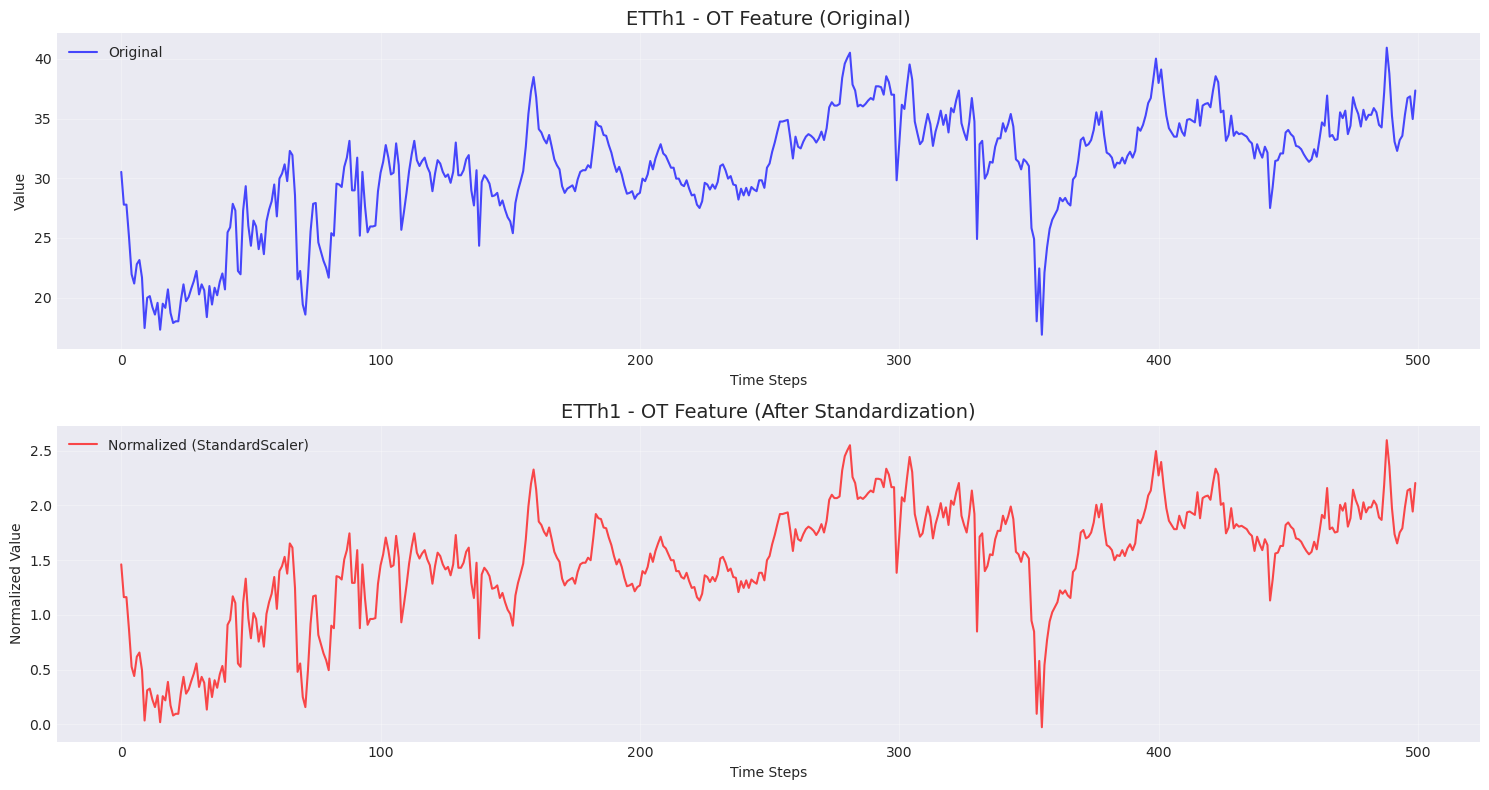

Original - Mean: 30.8457, Std: 4.7957
Normalized - Mean: 1.4948, Std: 0.5226


In [15]:
# Visualisasi data normalized vs original (ETTh1 sebagai contoh)
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# Original data (first 500 samples)
feature_idx = 6  # OT column
original_data = datasets_clean['ETTh1'].iloc[:500, feature_idx+1].values
normalized_data = prepared_datasets['ETTh1']['data']['train'][:500, feature_idx]

axes[0].plot(original_data, label='Original', color='blue', alpha=0.7)
axes[0].set_title('ETTh1 - OT Feature (Original)', fontsize=14)
axes[0].set_xlabel('Time Steps')
axes[0].set_ylabel('Value')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(normalized_data, label='Normalized (StandardScaler)', color='red', alpha=0.7)
axes[1].set_title('ETTh1 - OT Feature (After Standardization)', fontsize=14)
axes[1].set_xlabel('Time Steps')
axes[1].set_ylabel('Normalized Value')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Original - Mean: {original_data.mean():.4f}, Std: {original_data.std():.4f}")
print(f"Normalized - Mean: {normalized_data.mean():.4f}, Std: {normalized_data.std():.4f}")

## 8. Create Sliding Windows untuk TimeMixer

Membuat sliding window sequences sesuai dengan parameter TimeMixer:
- **seq_len** (lookback): 168
- **label_len**: 0 (TimeMixer tidak menggunakan label_len)
- **pred_len** (horizon): 96, 192, 336, 720

In [16]:
def create_sliding_windows(data, time_features, seq_len=168, label_len=0, pred_len=96):
    """
    Create sliding window sequences untuk time series forecasting
    
    Args:
        data: Normalized data array (timesteps, features)
        time_features: Time feature array (timesteps, time_dims)
        seq_len: Lookback window size
        label_len: Label length (overlap, 0 untuk TimeMixer)
        pred_len: Prediction horizon
    
    Returns:
        sequences: dict dengan 'x', 'y', 'x_mark', 'y_mark'
    """
    num_samples = len(data) - seq_len - pred_len + 1
    
    seq_x_list = []
    seq_y_list = []
    seq_x_mark_list = []
    seq_y_mark_list = []
    
    for i in range(num_samples):
        # Input sequence
        s_begin = i
        s_end = s_begin + seq_len
        
        # Output sequence
        r_begin = s_end - label_len
        r_end = r_begin + label_len + pred_len
        
        seq_x = data[s_begin:s_end]
        seq_y = data[r_begin:r_end]
        seq_x_mark = time_features[s_begin:s_end]
        seq_y_mark = time_features[r_begin:r_end]
        
        seq_x_list.append(seq_x)
        seq_y_list.append(seq_y)
        seq_x_mark_list.append(seq_x_mark)
        seq_y_mark_list.append(seq_y_mark)
    
    return {
        'x': np.array(seq_x_list),
        'y': np.array(seq_y_list),
        'x_mark': np.array(seq_x_mark_list),
        'y_mark': np.array(seq_y_mark_list)
    }

# Test dengan ETTh1, pred_len=96
print("Creating sliding windows for ETTh1 (pred_len=96)...")
windows_test = create_sliding_windows(
    prepared_datasets['ETTh1']['data']['train'],
    prepared_datasets['ETTh1']['time_features']['train'],
    seq_len=168,
    label_len=0,
    pred_len=96
)

print(f"\nWindows created:")
print(f"  Input sequences (X):      {windows_test['x'].shape}")
print(f"  Output sequences (Y):     {windows_test['y'].shape}")
print(f"  Input time features:      {windows_test['x_mark'].shape}")
print(f"  Output time features:     {windows_test['y_mark'].shape}")

print(f"\nInterpretation:")
print(f"  - {windows_test['x'].shape[0]} total sequences")
print(f"  - Each input: {windows_test['x'].shape[1]} timesteps × {windows_test['x'].shape[2]} features")
print(f"  - Each output: {windows_test['y'].shape[1]} timesteps × {windows_test['y'].shape[2]} features")

Creating sliding windows for ETTh1 (pred_len=96)...

Windows created:
  Input sequences (X):      (8377, 168, 7)
  Output sequences (Y):     (8377, 96, 7)
  Input time features:      (8377, 168, 4)
  Output time features:     (8377, 96, 4)

Interpretation:
  - 8377 total sequences
  - Each input: 168 timesteps × 7 features
  - Each output: 96 timesteps × 7 features


### Prepare Windows untuk Multiple Prediction Lengths

TimeMixer biasanya diuji dengan multiple prediction horizons: 96, 192, 336, 720

In [17]:
def prepare_all_windows(prepared_data, pred_lens=[96, 192, 336, 720], seq_len=168):
    """
    Prepare sliding windows untuk semua prediction lengths
    """
    all_windows = {}
    
    for pred_len in pred_lens:
        windows = {}
        
        for split in ['train', 'val', 'test']:
            windows[split] = create_sliding_windows(
                prepared_data['data'][split],
                prepared_data['time_features'][split],
                seq_len=seq_len,
                label_len=0,
                pred_len=pred_len
            )
        
        all_windows[f'pred_{pred_len}'] = windows
    
    return all_windows

# Prepare windows untuk ETTh1
print("Preparing sliding windows for ETTh1 (all prediction lengths)...")
etth1_windows = prepare_all_windows(prepared_datasets['ETTh1'])

print("\nWindows summary for ETTh1:")
print("="*60)
for pred_key, splits in etth1_windows.items():
    print(f"\n{pred_key}:")
    for split_name, windows in splits.items():
        print(f"  {split_name:5s}: {windows['x'].shape[0]:5d} sequences | "
              f"X: {windows['x'].shape[1:]} | Y: {windows['y'].shape[1:]}")

Preparing sliding windows for ETTh1 (all prediction lengths)...

Windows summary for ETTh1:

pred_96:
  train:  8377 sequences | X: (168, 7) | Y: (96, 7)
  val  :  2785 sequences | X: (168, 7) | Y: (96, 7)
  test :  2785 sequences | X: (168, 7) | Y: (96, 7)

pred_192:
  train:  8281 sequences | X: (168, 7) | Y: (192, 7)
  val  :  2689 sequences | X: (168, 7) | Y: (192, 7)
  test :  2689 sequences | X: (168, 7) | Y: (192, 7)

pred_336:
  train:  8137 sequences | X: (168, 7) | Y: (336, 7)
  val  :  2545 sequences | X: (168, 7) | Y: (336, 7)
  test :  2545 sequences | X: (168, 7) | Y: (336, 7)

pred_720:
  train:  7753 sequences | X: (168, 7) | Y: (720, 7)
  val  :  2161 sequences | X: (168, 7) | Y: (720, 7)
  test :  2161 sequences | X: (168, 7) | Y: (720, 7)


## 9. Visualisasi Sample Windows

Mari kita visualisasi bagaimana sliding windows bekerja

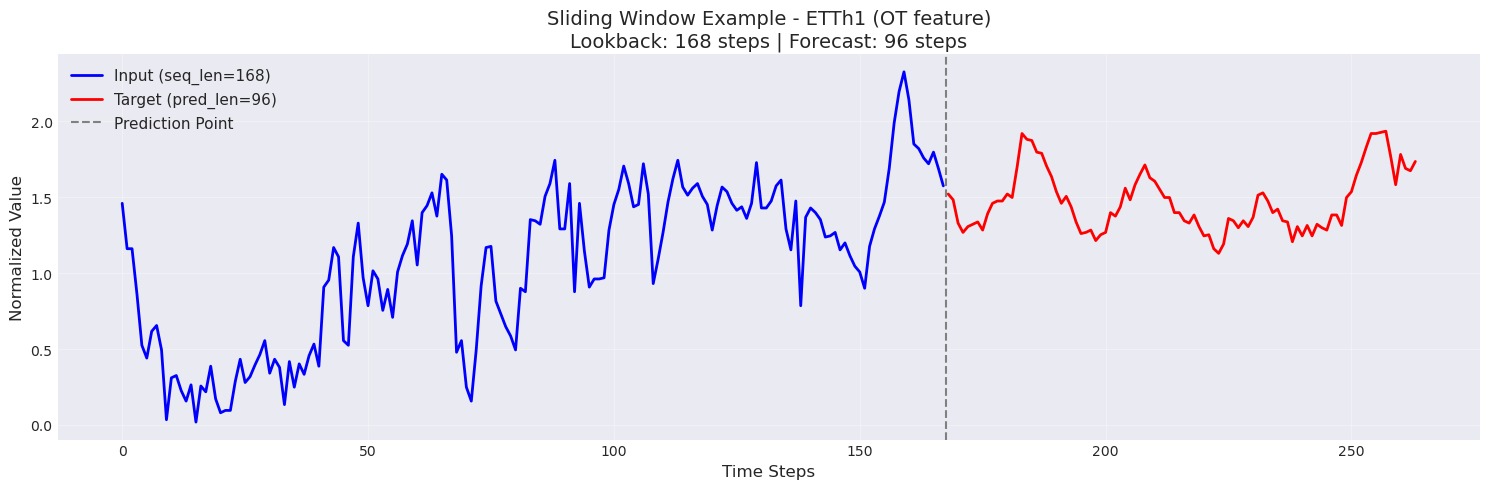

Window structure:
  - Input window covers timesteps: 0 to 167
  - Output window covers timesteps: 168 to 263
  - Model learns to predict 96 future steps based on 168 past steps


In [18]:
# Visualisasi sliding window
sample_idx = 0
pred_len = 96
feature_idx = 6  # OT feature

# Ambil satu sample
sample_x = etth1_windows['pred_96']['train']['x'][sample_idx]
sample_y = etth1_windows['pred_96']['train']['y'][sample_idx]

# Plot
fig, ax = plt.subplots(figsize=(15, 5))

# Input sequence (lookback)
x_data = sample_x[:, feature_idx]
x_timesteps = np.arange(len(x_data))

# Output sequence (prediction)
y_data = sample_y[:, feature_idx]
y_timesteps = np.arange(len(x_data), len(x_data) + len(y_data))

ax.plot(x_timesteps, x_data, 'b-', label=f'Input (seq_len={len(x_data)})', linewidth=2)
ax.plot(y_timesteps, y_data, 'r-', label=f'Target (pred_len={len(y_data)})', linewidth=2)

# Visual separator
ax.axvline(x=len(x_data)-0.5, color='gray', linestyle='--', linewidth=1.5, label='Prediction Point')

ax.set_xlabel('Time Steps', fontsize=12)
ax.set_ylabel('Normalized Value', fontsize=12)
ax.set_title(f'Sliding Window Example - ETTh1 (OT feature)\nLookback: {len(x_data)} steps | Forecast: {len(y_data)} steps', 
             fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Window structure:")
print(f"  - Input window covers timesteps: 0 to {len(x_data)-1}")
print(f"  - Output window covers timesteps: {len(x_data)} to {len(x_data)+len(y_data)-1}")
print(f"  - Model learns to predict {len(y_data)} future steps based on {len(x_data)} past steps")

## 10. Save Processed Data

Simpan data yang sudah diproses untuk digunakan dalam training TimeMixer

In [19]:
import pickle

# Buat direktori untuk menyimpan hasil preprocessing
output_dir = './preprocessed_data'
os.makedirs(output_dir, exist_ok=True)

print("Saving preprocessed data...")
print("="*60)

# Save prepared datasets (dengan scaler dan borders)
for name, data in prepared_datasets.items():
    output_file = os.path.join(output_dir, f'{name}_prepared.pkl')
    
    with open(output_file, 'wb') as f:
        pickle.dump(data, f)
    
    print(f"✓ Saved {name}_prepared.pkl")
    print(f"  Contains: data splits, scaler, borders, feature names")

print("\n" + "="*60)
print(f"All preprocessed data saved to: {output_dir}")

Saving preprocessed data...
✓ Saved ETTh1_prepared.pkl
  Contains: data splits, scaler, borders, feature names
✓ Saved ETTh2_prepared.pkl
  Contains: data splits, scaler, borders, feature names
✓ Saved Weather_prepared.pkl
  Contains: data splits, scaler, borders, feature names
✓ Saved Traffic_prepared.pkl
  Contains: data splits, scaler, borders, feature names

All preprocessed data saved to: ./preprocessed_data


### Contoh Load Preprocessed Data

Begini cara load kembali data yang sudah diproses:

In [20]:
# Contoh load data
example_file = os.path.join(output_dir, 'ETTh1_prepared.pkl')

with open(example_file, 'rb') as f:
    loaded_data = pickle.load(f)

print("Loaded data structure:")
print(f"  Keys: {list(loaded_data.keys())}")
print(f"\nData splits available:")
for split in loaded_data['data'].keys():
    print(f"  - {split}: {loaded_data['data'][split].shape}")
print(f"\nFeatures: {loaded_data['feature_names']}")
print(f"\nScaler mean: {loaded_data['scaler'].mean_[:3]}... (first 3)")
print(f"Scaler std: {loaded_data['scaler'].scale_[:3]}... (first 3)")

Loaded data structure:
  Keys: ['data', 'time_features', 'scaler', 'borders', 'feature_names']

Data splits available:
  - train: (8640, 7)
  - val: (3048, 7)
  - test: (3048, 7)

Features: ['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT']

Scaler mean: [7.93774225 2.02103866 5.0797706 ]... (first 3)
Scaler std: [5.81274941 2.09010465 5.51879358]... (first 3)


## 11. Summary dan Statistik Dataset

Ringkasan dari semua dataset yang telah diproses

In [21]:
# Create summary table
summary_data = []

for name, data in prepared_datasets.items():
    summary_data.append({
        'Dataset': name,
        'Features': len(data['feature_names']),
        'Train Samples': data['data']['train'].shape[0],
        'Val Samples': data['data']['val'].shape[0],
        'Test Samples': data['data']['test'].shape[0],
        'Total Length': sum([data['data'][s].shape[0] for s in ['train', 'val', 'test']]),
        'Time Dims': data['time_features']['train'].shape[1]
    })

summary_df = pd.DataFrame(summary_data)
print("="*80)
print("PREPROCESSING SUMMARY")
print("="*80)
print(summary_df.to_string(index=False))

print("\n" + "="*80)
print("FEATURE DETAILS")
print("="*80)
for name, data in prepared_datasets.items():
    print(f"\n{name}: {data['feature_names']}")

PREPROCESSING SUMMARY
Dataset  Features  Train Samples  Val Samples  Test Samples  Total Length  Time Dims
  ETTh1         7           8640         3048          3048         14736          4
  ETTh2         7           8640         3048          3048         14736          4
Weather        21          36887         5438         10707         53032          4
Traffic       862          12280         1924          3676         17880          4

FEATURE DETAILS

ETTh1: ['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT']

ETTh2: ['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT']

Weather: ['p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)', 'rain (mm)', 'raining (s)', 'SWDR (W/m�)', 'PAR (�mol/m�/s)', 'max. PAR (�mol/m�/s)', 'Tlog (degC)', 'OT']

Traffic: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15

## 12. Cara Menggunakan Data untuk TimeMixer

Berikut adalah contoh bagaimana menggunakan data yang sudah diproses untuk training TimeMixer

### Integrasi dengan DataLoader PyTorch

Data yang sudah diproses dapat langsung digunakan dengan PyTorch DataLoader:

In [22]:
"""
CONTOH PENGGUNAAN DENGAN PYTORCH:

```python
import torch
from torch.utils.data import Dataset, DataLoader

class TimeSeriesDataset(Dataset):
    def __init__(self, data, time_features, seq_len=168, pred_len=96):
        self.data = data
        self.time_features = time_features
        self.seq_len = seq_len
        self.pred_len = pred_len
        
    def __len__(self):
        return len(self.data) - self.seq_len - self.pred_len + 1
    
    def __getitem__(self, idx):
        # Input sequence
        s_begin = idx
        s_end = s_begin + self.seq_len
        
        # Output sequence
        r_begin = s_end
        r_end = r_begin + self.pred_len
        
        seq_x = torch.FloatTensor(self.data[s_begin:s_end])
        seq_y = torch.FloatTensor(self.data[r_begin:r_end])
        seq_x_mark = torch.FloatTensor(self.time_features[s_begin:s_end])
        seq_y_mark = torch.FloatTensor(self.time_features[r_begin:r_end])
        
        return seq_x, seq_y, seq_x_mark, seq_y_mark

# Load preprocessed data
with open('./preprocessed_data/ETTh1_prepared.pkl', 'rb') as f:
    etth1_data = pickle.load(f)

# Create dataset
train_dataset = TimeSeriesDataset(
    etth1_data['data']['train'],
    etth1_data['time_features']['train'],
    seq_len=168,
    pred_len=96
)

# Create dataloader
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4
)

# Training loop
for batch_x, batch_y, batch_x_mark, batch_y_mark in train_loader:
    # batch_x: (batch_size, seq_len, features)
    # batch_y: (batch_size, pred_len, features)
    # Pass to TimeMixer model...
    pass
```
"""
print("Lihat kode contoh di atas untuk integrasi dengan PyTorch!")

Lihat kode contoh di atas untuk integrasi dengan PyTorch!


### Command untuk Training TimeMixer

Untuk menjalankan training menggunakan script bash yang sudah ada:

```bash
# ETTh1
bash scripts/long_term_forecast/ETT_script/TimeMixer_ETTh1.sh

# ETTh2
bash scripts/long_term_forecast/ETT_script/TimeMixer_ETTh2.sh

# Weather
bash scripts/long_term_forecast/Weather_script/TimeMixer.sh

# Traffic
bash scripts/long_term_forecast/Traffic_script/TimeMixer.sh
```

Atau menggunakan `run.py` langsung:

```bash
python run.py \
  --task_name long_term_forecast \
  --is_training 1 \
  --root_path ./dataset/ETT-small/ \
  --data_path ETTh1.csv \
  --model_id ETTh1_168_96 \
  --model TimeMixer \
  --data ETTh1 \
  --features M \
  --seq_len 168 \
  --label_len 0 \
  --pred_len 96 \
  --e_layers 2 \
  --enc_in 7 \
  --c_out 7 \
  --d_model 16 \
  --d_ff 32 \
  --down_sampling_layers 3 \
  --down_sampling_window 2 \
  --learning_rate 0.01 \
  --batch_size 128 \
  --train_epochs 10
```

---

## Kesimpulan

Notebook ini telah menunjukkan proses lengkap preprocessing data untuk TimeMixer:

### ✅ Langkah-langkah yang telah dilakukan:

1. **Load Raw Data**: Memuat dataset ETTh1, ETTh2, Weather, dan Traffic
2. **Explorasi**: Memahami struktur, dimensi, dan karakteristik data
3. **Handle Missing Values**: Menangani nilai yang hilang (jika ada)
4. **Extract Time Features**: Membuat fitur temporal (month, day, weekday, hour)
5. **Data Splitting**: Membagi data ke train/val/test dengan border yang tepat
6. **Standardization**: Normalisasi menggunakan StandardScaler (fit pada training saja)
7. **Sliding Windows**: Membuat window sequences untuk berbagai prediction horizons
8. **Save Data**: Menyimpan data preprocessed untuk digunakan kemudian

### 📊 Parameter TimeMixer yang digunakan:

- **seq_len**: 168 (1 week lookback untuk hourly data)
- **pred_len**: 96, 192, 336, 720 (multiple forecasting horizons)
- **features**: 'M' (multivariate forecasting)
- **d_model**: 16
- **d_ff**: 32
- **down_sampling_layers**: 3
- **down_sampling_window**: 2
- **timeenc**: 0 (discrete time features)

### 💾 Output:

Data yang sudah diproses tersimpan di `./preprocessed_data/` dengan format:
- `ETTh1_prepared.pkl`
- `ETTh2_prepared.pkl`
- `Weather_prepared.pkl`
- `Traffic_prepared.pkl`

Setiap file berisi:
- Data splits (train/val/test) yang sudah dinormalisasi
- Time features
- Scaler (untuk inverse transform)
- Borders (untuk referensi)
- Feature names

### 🚀 Langkah Selanjutnya:

1. Gunakan data preprocessed untuk training TimeMixer
2. Eksperimen dengan berbagai prediction lengths
3. Evaluasi performa model pada test set
4. Gunakan scaler untuk inverse transform predictions ke skala original

---

**Catatan**: Data loader yang digunakan dalam `data_provider/data_loader.py` sudah mengimplementasikan pipeline preprocessing yang sama, sehingga untuk training Anda bisa langsung menggunakan script yang ada atau menggunakan data yang sudah di-preprocess ini.